# Numerical Computation of The Bayes Update Rule for Bayesian Adaptive Filtering

This notebook aims to implement through numerical integration the unidimensional bayesian update rule for general distributions in both the prior and the likelihood.

$$ f_m(\theta_{t,m} | y_{1:t}) \propto f_m(\theta_{t,m} | y_{1:t-1})\,f_{\zeta_m}\!\big(y_t - x_{t,m}\theta_{t,m}\big) $$

In [1]:
import numpy as np
import scipy.signal
import scipy
import numba
from numba import njit, prange, objmode, types
from typing import List, Optional, Any, AnyStr, TypedDict
from collections.abc import Callable
from matplotlib import pyplot as plt
from numba.types import Array, complex128, float64

from IPython.display import clear_output

In [2]:
from numba_progress import ProgressBar

## Framework functions

### Autocorrelation Matrix

In [3]:
@njit
def autocorr_matrix_estimate(signal, M = 4):
  # Inicializa as variáveis
  x_temp, R = np.zeros((M, 1)), np.zeros((M, M))

  for x in signal:
    # Desloca as amostras e insere um novo valor na primeira posição
    x_temp[1:], x_temp[0] = x_temp[:-1], x

    # Calcula a matriz de correlação e acumula
    R += x_temp @ x_temp.T

  # Retorna a matriz normalizada pelo tamanho do sinal
  return R/(signal.size)

@njit
def toeplitz(vector):
  L = len(vector)
  matrix = np.zeros((L,L))

  for k in range(L):
      matrix[k, :k] = vector[k:0:-1]
      matrix[k, k:] = vector[:L-k]

  return matrix

@njit
def autocorr_matrix_calc(AR, var_v, M = None):
  # Autoregressive order
  L = len(AR) - 1
  # Number of autocorrelation samples to be computed
  if M is None:
    M = L

  # Initialize the vector containing the autocorrelation values
  rxx = np.zeros((M,))

  # State Space matrix describing the autoregressive process
  A = np.zeros((L,L))
  A[1:,:] = np.eye(L-1, M = L)
  A[0,:] = -AR[1:]

  # Intermediate values associated with the calclulation
  AA = np.kron(A,A);
  BB_vec_IL = np.zeros((L**2,))  # Effect of the matrix operating over the input data on the state space
  BB_vec_IL[0] = 1;
  I_L2 = np.eye(L**2)

  # Calculation of the autocorrelation matrix with the first L values
  vec_Rxx = var_v * np.linalg.inv(I_L2 - AA) @ BB_vec_IL

  # Save the first L values
  rxx[:L] = vec_Rxx[:L]

  # Compute the remaining values using the autoregressive coeficients
  if M > L:
    for k in range(L, M):
      if k == L:
        rxx[k] = - AR[1:] @ rxx[(k-1)::-1]
      else:
        rxx[k] = - AR[1:] @ rxx[(k-1):(k - L - 1):-1]

  # Construct the autocorrelation matrix using the values in rxx
  R = toeplitz(rxx)

  return R

@njit
def AR_settling_time(AR, error = 0.01):
  L = len(AR) - 1
  A = np.zeros((L,L))
  A[1:,:] = np.eye(L-1, M = L)
  A[0,:] = -AR[1:]
  A = A.astype(np.complex64)

  eigen_values = np.linalg.eigvals(A)
  slowest_decay_ratio = np.max(np.abs(eigen_values))
  if slowest_decay_ratio >= 1:
    raise(Exception('The given AR process will not converge'))

  settling_time = np.log(error)/np.log(slowest_decay_ratio)
  return int(np.ceil(settling_time))

### Operations

In [4]:
@njit
def shift(new_x_sample, x_window):
  L = len(x_window)
  new_x_window = np.zeros(L)
  new_x_window[0] = new_x_sample
  new_x_window[1:] = x_window[:-1]
  return new_x_window

@njit
def filter(a, b, x):
  K = len(x)
  L_a = len(a)
  L_b = len(b)
  y_vec = np.zeros(L_a - 1)
  x_vec = np.zeros(L_b)
  if a[0] != 0.0:
    b = b/a[0]
    a = a[1:]/a[0]
  else:
    raise(Exception('a[0] can NOT be zero!'))
  y = np.zeros(K)

  for k in range(K):
    x_vec = shift(x[k], x_vec)

    y[k] = b @ x_vec - a @ y_vec
    y_vec = shift(y[k], y_vec)

  return y

### Adaptive Filters

In [5]:
NLMS_params = np.dtype([("label", "U20"), # Unicode string up to 20 characters
                        ("mu", "f8"),     # 64-bit floating-point number
                        ("delta", "f8")   # 64-bit floating-point number
                      ])

sKF_params = np.dtype([("label", "U20"), # Unicode string up to 20 characters
                        ("epsilon", "f8"),     # 64-bit floating-point number
                        ("var_eta", "f8"),   # 64-bit floating-point number
                        ("v_tilde_0", "f8")   # 64-bit floating-point number
                      ])

sKF_L_params = np.dtype([("label", "U20"), # Unicode string up to 20 characters
                        ("epsilon", "f8"),     # 64-bit floating-point number
                        ("b_eta", "f8"),   # Escala de la distribución de Laplace
                        ("v_tilde_0", "f8")   # 64-bit floating-point number
                      ])

@njit
def NLMS_algorithm(N, x, d, h0, parameters):
  h = h0
  mu = parameters.mu
  delta = parameters.delta

  L = len(h)
  y = np.zeros((N,))
  e = np.zeros((N,))
  xtemp = np.zeros(L)

  for k in range(0,N):
    xtemp = shift(x[k], xtemp)
    y[k] = h @ xtemp
    e[k] = d[k] - y[k]

    if k >= L:
      x_power = delta + xtemp @ xtemp
      h = h + mu*xtemp*e[k]/x_power

  return {'h': h, 'y': y, 'e': e}

def sKF_algorithm(N, x, d, h0, parameters):
  h = h0
  epsilon = parameters["epsilon"]
  var_eta = parameters["var_eta"]
  v_tilde_0 = parameters["v_tilde_0"]

  # normalize x
  # regularization = 1e-3
  # x_reg = np.sign(x) * (np.abs(x) + regularization)

  L = len(h)
  y = np.zeros((N,))
  e = np.zeros((N,))
  xtemp = np.zeros(L)
  v=v_tilde_0
  h_hist = np.zeros((N, L))
  v_hist = np.zeros((N, L))
  # d: salida del sistema con ruido
  # y: salida estimada
  for k in range(0,N):
    xtemp = shift(x[k], xtemp)
    y[k] = h @ xtemp
    e[k] = d[k] - y[k]
    h_hist[k] = h
    v_hist[k] = v

    if k >= L:
      # predict
      v += epsilon
      # update
      norm = xtemp @ xtemp
      s = var_eta + v * norm
      h = h + xtemp * (v * e[k]/s) # not h+= because it would mutate h0
      v = v * (1 - (v * norm) / (L * s)) 

  return {'h': h_hist, 'y': y, 'e': e, 'v': v_hist}

def sKF_L_algorithm(N, x, d, h0, parameters):
  h = h0
  epsilon = parameters["epsilon"]
  b_eta = parameters["b_eta"]
  v_tilde_0 = parameters["v_tilde_0"]

  # normalize x
  # regularization = 1e-3
  # x_reg = np.sign(x) * (np.abs(x) + regularization)

  L = len(h)
  y = np.zeros((N,))
  e = np.zeros((N,))
  xtemp = np.zeros(L)
  v=v_tilde_0
  h_hist = np.zeros((N, L))
  v_hist = np.zeros((N, L))
  # d: salida del sistema con ruido
  # y: salida estimada
  for k in range(0,N):
    xtemp = shift(x[k], xtemp)
    y[k] = h @ xtemp
    e[k] = d[k] - y[k]
    h_hist[k] = h
    v_hist[k] = v

    if k >= L:
      # predict
      v += epsilon
      # update
      norm = xtemp @ xtemp
      s = b_eta * abs(e[k]) + v * norm
      h = h + xtemp * (v * e[k]/s) # not h+= because it would mutate h0
      v = v * (1 - (v * norm) / (L * s)) 

  return {'h': h_hist, 'y': y, 'e': e, 'v': v_hist}

### Environment

In [6]:
@njit
def std_behavior(N, ho, var_x, var_v, AR, settling_time = 0):
  # AR process order and filter length
  P = len(AR)
  L = len(ho)

  # Determine the noise signal
  v = np.sqrt(var_v)*np.random.randn(N)

  # Determine the input signal x through a AR process
  x = np.random.randn(N + settling_time + L)

  # Generate the correlated signal
  AR = AR/AR[0]
  aux_Rxx = autocorr_matrix_calc(AR, 1, M = len(AR) - 1)
  b = np.sqrt(var_x/aux_Rxx[0,0])
  x = filter(AR, np.array([b]), x)[settling_time:]

  # Determine the desired signal
  d = v + np.convolve(ho, x, mode = 'full')[L:N+L]
  x = x[L:N+L]

  return {'x': x, 'v': v, 'd': d}

@njit
def laplacian_noise_behavior(N, ho, var_x, scale_v, AR, settling_time = 0):
  # AR process order and filter length
  P = len(AR)
  L = len(ho)

  # Determine the noise signal
  v = np.random.laplace(loc=0.0, scale=scale_v, size=(N,))

  # Determine the input signal x through a AR process
  x = np.random.randn(N + settling_time + L)

  # Generate the correlated signal
  AR = AR/AR[0]
  aux_Rxx = autocorr_matrix_calc(AR, 1, M = len(AR) - 1)
  b = np.sqrt(var_x/aux_Rxx[0,0])
  x = filter(AR, np.array([b]), x)[settling_time:]

  # Determine the desired signal
  d = v + np.convolve(ho, x, mode = 'full')[L:N+L]
  x = x[L:N+L]

  return {'x': x, 'v': v, 'd': d}

def MC_Simulations_Modular(N, NR, ho, var_x, var_v, h0, Algorithms, Parameters, AR, PBar = None):
  L = len(h0)
  N_Algorithms = len(Algorithms)

  tau = AR_settling_time(AR)
  measure_init = lambda taps, N_iter: {'h': np.zeros((N_iter, taps)),
                                       'J': np.zeros(N_iter),
                                       'Jex': np.zeros(N_iter)}

  measures = {Parameters[k]["label"]: measure_init(L, N) for k in range(N_Algorithms)}

  for k in range(NR):
    signals = std_behavior(N, ho, var_x, var_v, AR, tau)
    x = signals['x']
    d = signals['d']

    for c in range(N_Algorithms):
      label = Parameters[c]["label"]
      algorithm_signals = Algorithms[c](N, x, d, h0, Parameters[c])
      measures[label]['h'] += algorithm_signals['h']
      measures[label]['J'] += algorithm_signals['e']**2
      measures[label]['Jex'] += (algorithm_signals['e']- signals['v'])**2

    if not PBar is None:
      PBar.update(1)
    else:
      print(f'Realization {k} out of {NR}')

  for k in range(N_Algorithms):
    label = Parameters[k]["label"]
    measures[label]['h'] /= NR
    measures[label]['J'] /= NR
    measures[label]['Jex'] /= NR

  return measures


# COPY PASTE FOR RETURNING VARIANCE, FOR COMPARING
def MC_Simulations_Modular_Variance(N, NR, ho, var_x, var_v, h0, Algorithms, Parameters, AR, PBar = None):
  L = len(h0)
  N_Algorithms = len(Algorithms)
  tau = AR_settling_time(AR)
  measure_init = lambda taps, N_iter: {'h': np.zeros((N_iter, taps)),
                                       'J': np.zeros(N_iter),
                                       'Jex': np.zeros(N_iter),
                                       'var': np.zeros((N_iter, taps))}

  measures = {Parameters[k]["label"]: measure_init(L, N) for k in range(N_Algorithms)}

  for k in range(NR):
    signals = std_behavior(N, ho, var_x, var_v, AR, tau)
    x = signals['x']
    d = signals['d']

    for c in range(N_Algorithms):
      label = Parameters[c]["label"]
      algorithm_signals = Algorithms[c](N, x, d, h0, Parameters[c])
      measures[label]['h'] += algorithm_signals['h']
      measures[label]['J'] += algorithm_signals['e']**2
      measures[label]['Jex'] += (algorithm_signals['e']- signals['v'])**2
      measures[label]['var'] += algorithm_signals['v']

    if not PBar is None:
      PBar.update(1)
    else:
      print(f'Realization {k} out of {NR}')

  for k in range(N_Algorithms):
    label = Parameters[k]["label"]
    measures[label]['h'] /= NR
    measures[label]['J'] /= NR
    measures[label]['Jex'] /= NR
    measures[label]['var'] /= NR

  return measures

## Simulations

In [7]:
NR = 200
N = int(100e3)
L = 64
ho = np.sinc(np.linspace(0,1,L))
ho = ho/np.linalg.norm(ho)
h0 = np.zeros(L)
var_x = 1
var_v = 1e-3
#AR = np.array([1.0, 0.0])
#AR = np.array([1.0, -0.6, 0.85])
AR = np.array([1.0, -0.9, 0.95, -0.8, 0.8])

mu = 0.1
delta = 1e-3

# sKF
epsilon = 1e-4
var_eta = 1e-3
v_tilde_0 = 1e-3

Algorithms = [NLMS_algorithm, sKF_algorithm]
NLMS_Parameters = np.void(("NLMS", mu, delta), dtype=NLMS_params)
sKF_Parameters = np.void(("sKF", epsilon, var_eta, v_tilde_0), dtype=sKF_params)
Alg_Parameters = [NLMS_Parameters, sKF_Parameters]

### Autocorrelation Matrix Test

In [8]:
# Test the autorregressive process
tau = AR_settling_time(AR)

signals = std_behavior(N, ho, var_x, var_v, AR, tau)
x = signals['x']
d = signals['d']

print(tau)

/var/folders/0y/901xwybs5msgqgqgdw7c8r340000gn/T/ipykernel_55525/2869619280.py:15: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 1, 'C', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  aux_Rxx = autocorr_matrix_calc(AR, 1, M = len(AR) - 1)


85


<StemContainer object of 3 artists>

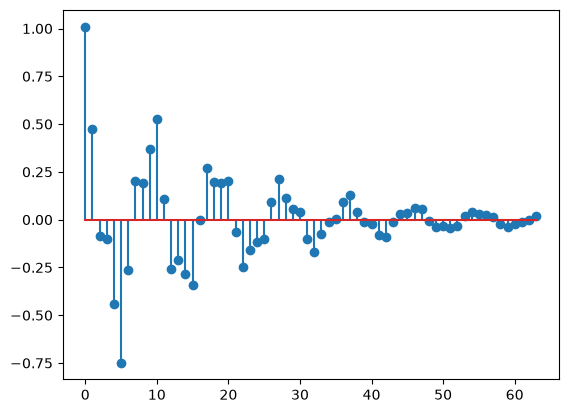

In [9]:
Rxx_est = autocorr_matrix_estimate(x, M = L)
rxx_est = Rxx_est[0,:]

plt.stem(rxx_est)

<StemContainer object of 3 artists>

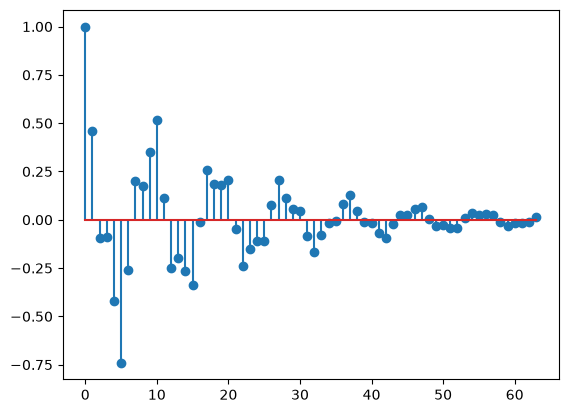

In [10]:
aux = autocorr_matrix_calc(AR, 1, M = len(AR) - 1)
var_w = var_x/aux[0,0]

Rxx = autocorr_matrix_calc(AR, var_w, M = L)
rxx = Rxx[0,:]

plt.stem(rxx[:])

In [11]:
print(f"Cosine Similarity: {rxx @ rxx_est / (np.linalg.norm(rxx)*np.linalg.norm(rxx_est))}")
print(f"Normalized Distance: {np.linalg.norm(Rxx - Rxx_est)/np.linalg.norm(Rxx)}")

Cosine Similarity: 0.9994266662422784
Normalized Distance: 0.03764362182816132


### Monte Carlo Simulations

In [12]:
Rxx = autocorr_matrix_calc(AR, var_w, M = L)
eig = np.linalg.eigvals(Rxx)
chi = np.max(eig)/np.min(eig)
print(f'Eigenvalue spread: {chi:.4} \n')

Eigenvalue spread: (831.9+0j) 



#### Bayesian Numerical Filter

##### Functions

In [21]:
skf_int_params = np.dtype([("label", "U20"),  # Unicode string up to 20 characters
                           ("epsilon", "f8"), # 64-bit floating-point number
                           ("var_theta_0", "f8"),  # 64-bit floating-point number
                           ("var_eta", "f8"), # 64-bit floating-point number
                           ("dx_factor", "f8"),
                           ("min_std_deviations", "f8")])

skf_L_int_params = np.dtype([("label", "U20"),  # Unicode string up to 20 characters
                           ("epsilon", "f8"), # 64-bit floating-point number
                           ("var_theta_0", "f8"),  # 64-bit floating-point number
                           ("b_eta", "f8"), # 64-bit floating-point number
                           ("dx_factor", "f8"),
                           ("min_std_deviations", "f8")])

gaussian_params = np.dtype([("mean", "f8"),
                            ("variance", "f8")])
laplacian_params = np.dtype([("mean", "f8"),
                            ("b", "f8")])

_float_array_1d = types.float64[:]

@njit
def gaussian_pdf(x, params: gaussian_params):
  return (1/np.sqrt(2*np.pi*params.variance))*np.exp(-(x-params.mean)**2/(2*params.variance))

@njit
def laplacian_pdf(x, params: laplacian_params):
  return (1/(2*params.b))*np.exp(-np.abs(x-params.mean)/params.b)

@njit
def _compute_individual_interferences_pdfs(base_space, theta_pdf_function, pdf_parameters, input_data, regularization = 1e-15):
  f_inter_list = []
  for x in input_data:
    interference_pdf = theta_pdf_function(base_space/(regularization + np.abs(x)), pdf_parameters)
    interference_pdf /= regularization + np.abs(x)
    f_inter_list.append(interference_pdf)

  return f_inter_list

@njit
def fft_integral_convolve(f, g, dx):
    """
    Computes the numerical convolution integral using the FFT.
    Numba compatible.

    Parameters:
        f (np.ndarray): 1D array of first function samples.
        g (np.ndarray): 1D array of second function samples.
        dx (float): Grid spacing/step size.

    Returns:
        np.ndarray: 1D array containing the corrected trapezoidal convolution.
    """
    input_len = len(f)

    with objmode(riemann_sum=_float_array_1d):
        riemann_sum = scipy.signal.fftconvolve(f, g, mode='full')

    return dx * riemann_sum[input_len//2:3*input_len//2]

# Tipos de array estáticos exigidos pelo objmode
Complex1D = Array(complex128, 1, "C")
Complex2D = Array(complex128, 2, "C")
Float1D   = Array(float64, 1, "C")

@njit
def integral_convolve_from_base_pdf(full_signals,
                                    base_signal,
                                    freq_scalings,
                                    translations,
                                    center_sample,
                                    dx,
                                    log_sum = False):
    """
    Implements efficiently the convolution integral assuming that I signals f(t)
    are being convolved as well as J signals g(.) obtained from time scaling
    ___               ___
    | |Fourier{f_i(t)}| |Fourier{g[(t-T_j)/C_j]}
     i                 j
    Note that the Fourier transforms are approximations of the continuous time
    Fourier transform, therefore, assuming proper sampling, continuous time
    properties and linear interpolation are used.
    Allows robust treatment of time scalings like C_j --> 0.
    """
    I, N = full_signals.shape
    J = len(freq_scalings)
    K = I + J
    N_conv = K * N - (K - 1)

    # 1. FFT of all PDFs
    with objmode(espectres=Complex2D, base_spectre=Complex1D):
        espectres = scipy.fft.rfft(full_signals, n=N_conv, axis=1)
        base_spectre = scipy.fft.rfft(base_signal, n=N_conv)

    # 2. Correct the PDF center displacement
    freq_space = np.arange(0, (N_conv//2+1), 1)
    centering_vector = np.exp(2j*np.pi*center_sample*freq_space/N_conv)
    base_spectre *= centering_vector

    # 3. Reescale the PDF Fourier transform
    NF = len(base_spectre)
    input_space = np.arange(0, NF, 1)
    interpolated_spectres = np.zeros((J, NF), np.complex128)
    for j in range(J):
      interpolated_spectres[j] = np.interp(freq_scalings[j]*input_space,
                                           input_space,
                                           base_spectre)
    espectres = np.append(espectres, interpolated_spectres, axis=0)

    # 4. Product of all FFTs
    if log_sum:
      log_espectre_prod = np.log(espectres[0])
      for k in range(1, K):
          log_espectre_prod += np.log(espectres[k])
      total_translation = J*center_sample + (translations @ freq_scalings)/dx
      log_espectre_prod += -2j*np.pi*total_translation*freq_space/N_conv
      espectre_prod = np.exp(log_espectre_prod)
    else:
      espectre_prod = espectres[0].copy()
      for k in range(1, K):
          espectre_prod *= espectres[k]
      total_translation = J*center_sample + (translations @ freq_scalings)/dx
      espectre_prod *= np.exp(-2j*np.pi*total_translation*freq_space/N_conv)

    # 5. Inverse FFT tranform
    with objmode(y_full=Float1D):
        y_full = scipy.fft.irfft(espectre_prod, n=N_conv)

    # 6. Windowing of the convolved signal
    start_idx = (K - 1) * (N // 2)
    end_idx = start_idx + N

    return y_full[start_idx:end_idx]*(dx ** (K - 1))

@njit
def _compute_composite_noise_pdf(f_eta, f_inter_list, dx):
  f_zeta = f_eta
  for f_inter in f_inter_list:
    f_zeta = fft_integral_convolve(f_zeta, f_inter, dx)
  return f_zeta

def _get_integration_range(relative_range,
                           var_tilde,
                           var_zeta,
                           d_k,
                           x_k,
                           w_k,
                           mean_S,
                           regularization = 1e-12):
  worst_std = np.sqrt(np.max([var_tilde, var_zeta]))
  prior_range = relative_range*np.sqrt(var_tilde)
  prior_limits = (np.min(w_k) - prior_range, np.max(w_k) + prior_range)

  reg_xk = regularization + np.abs(x_k)
  corrected_mean = reg_xk*np.abs(w_k) + (np.abs(d_k) + np.abs(mean_S))
  likelihood_range = np.max((relative_range*np.sqrt(var_zeta) + corrected_mean)/reg_xk)
  likelihood_limits = (-likelihood_range, likelihood_range)
  final_limits = (np.min((prior_limits[0], likelihood_limits[0])),
                  np.max((prior_limits[1], likelihood_limits[1])))

  return final_limits

def sKF_integral_algorithm(N, x, d, w0, parameters):
  w_hist = np.zeros((N, len(w0))) # Nuevo
  var_theta_hist = np.zeros((N, len(w0))) # NUEVO !!!!
  w = w0.copy()
  L = len(w)
  regularization = 1e-3
  x_reg = np.sign(x)*(np.abs(x) + regularization)

  scalar_var_theta = parameters["var_theta_0"]
  var_theta = scalar_var_theta*np.ones((L,))
  epsilon = parameters["epsilon"]
  var_eta = parameters["var_eta"]
  eta_parameters = np.void((0, var_eta), dtype=gaussian_params)

  #dx = np.min([epsilon, var_eta])*parameters.dx_factor
  relative_range = parameters["min_std_deviations"]

  y = np.zeros((N,))
  e = np.zeros((N,))
  xtemp = np.zeros(L)

  #print(f"w0: {w}")
  for k in range(0, N):
    xtemp = shift(x_reg[k], xtemp)
    y[k] = w @ xtemp
    e[k] = d[k] - y[k]

    w_hist[k] = w.copy() # NUEVO
    var_theta_hist[k] = scalar_var_theta.copy() # NUEVO
    if k >= L:
      var_tilde = scalar_var_theta + epsilon
      worst_var_zeta = var_eta + (np.linalg.norm(xtemp)**2)*var_tilde
      mean_S = y[k] - w*xtemp

      #print(f"Var_tilde: {var_tilde}; Var_eta: {var_eta}; Worst Var_zeta: {worst_var_zeta}")
      dx = np.sqrt(np.min([var_tilde, var_eta]))*parameters["dx_factor"]
      int_range = _get_integration_range(relative_range,
                           var_tilde,
                           worst_var_zeta,
                           d[k],
                           xtemp,
                           w,
                           mean_S)

      theta_parameters = np.void((0, var_tilde), dtype=gaussian_params)
      #base_space = np.arange(-int_range, int_range, dx)
      base_space = np.arange(int_range[0], int_range[1], dx)
      f_eta = gaussian_pdf(base_space, eta_parameters)
      #prior_m = gaussian_pdf(base_space, theta_parameters)
      #f_inter_list = np.array(_compute_individual_interferences_pdfs(base_space, gaussian_pdf, theta_parameters, xtemp))
      base_pdf = gaussian_pdf(base_space, theta_parameters)

      #print(f"Worst calculated var_zeta: {worst_var_zeta}")
      #print(f"dx: {dx}\nbase space length: {len(base_space)}")

      #plt.clf()
      for m in range(L):
        zeta_space = base_space + mean_S[m]
        #theta_m_space = base_space - w[m]
        likelihood_space = d[k] - xtemp[m]*base_space
        freq_scalings = np.abs(xtemp[np.arange(0,L,1) != m])

        inter_mask = ~np.zeros((L,), dtype=bool); inter_mask[m] = False
        #f_zeta = _compute_composite_noise_pdf(f_eta, f_inter_list[~inter_mask], dx)
        f_zeta = integral_convolve_from_base_pdf(np.array([f_eta]),
                                                 base_pdf,
                                                 freq_scalings,
                                                 np.zeros((L-1,)),
                                                 (len(f_eta)+1)//2,
                                                 dx)

        likelihood = np.interp(likelihood_space, zeta_space, f_zeta, left=0, right=0)
        prior_m = gaussian_pdf(base_space, np.void((w[m], var_tilde), dtype=gaussian_params))
        post_m = np.nan_to_num(np.exp(np.log(prior_m) + np.log(likelihood))) # Search for numerical stable implementations
        post_m /= np.trapezoid(post_m, dx=dx)

        #print(f"Obtained var_zeta {m}: {np.trapezoid(base_space**2*f_zeta, dx=dx)}")
        #plt.plot(base_space, np.interp(base_space, zeta_space, f_zeta, left=0, right=0))
        #plt.scatter([mean_S[m]], [np.max(f_zeta)])
        #print(f"d: {d[k]}; w[{m}]: {w[m]}; x[{m}]: {xtemp[m]}; S[{m}]: {mean_S[m]}")
        #pred_mean = (d[k] - mean_S[m])/xtemp[m]
        #print(f"Predicted_mean: {pred_mean}; Value at pred. mean: {np.interp(pred_mean, theta_m_space, likelihood, left=0, right=0)}; Max value: {np.max(f_zeta)}")
        #plt.plot(theta_m_space, abs(xtemp[m])*likelihood)
        #plt.scatter([pred_mean], [abs(xtemp[m])*np.max(likelihood)])

        #pred_base = w[m] + (d[k] - mean_S[m])/xtemp[m]
        #print(f"pred_base: {pred_base}; actual mean = {np.trapezoid(base_space*abs(xtemp[m])*likelihood, dx=dx)}")
        w[m] = np.trapezoid(base_space*post_m, dx=dx)
        var_theta[m] = np.trapezoid(((base_space-w[m])**2)*post_m, dx=dx)
        #plt.plot(base_space, post_m)
        #plt.scatter([w[m]],[np.max(post_m)])
        #print(np.shape(post_m))
        #print(f"var_theta[{m}]: {var_theta[m]}]")

      #print(f"x[{k}]: {xtemp}")
      #print(f"w[{k}]: {w}")
      #print("----------------------------------------------------")
      scalar_var_theta = np.mean(var_theta)
      # var_theta_hist[k] = var_theta

  return {'h': w_hist, 'y': y, 'e': e, 'v': var_theta_hist}

def sKF_L_integral_algorithm(N, x, d, w0, parameters):
  w = w0.copy()
  L = len(w)

  w_hist = np.zeros((N, len(w0)))
  var_theta_hist = np.zeros((N, len(w0)))

  scalar_var_theta = parameters["var_theta_0"]
  var_theta = scalar_var_theta*np.ones((L,))
  epsilon = parameters["epsilon"]
  b_eta = parameters["b_eta"]
  var_eta = 2*b_eta**2
  eta_parameters = np.void((0, b_eta), dtype=laplacian_params)

  relative_range = parameters["min_std_deviations"]

  y = np.zeros((N,))
  e = np.zeros((N,))
  xtemp = np.zeros(L)

  regularization = 1e-3
  x_reg = np.sign(x)*(np.abs(x) + regularization)

  #print(f"w0: {w}")
  for k in range(0, N):
    xtemp = shift(x_reg[k], xtemp)
    y[k] = w @ xtemp
    e[k] = d[k] - y[k]

    w_hist[k] = w.copy()
    var_theta_hist[k] = scalar_var_theta.copy()
    if k >= L:
      var_tilde = scalar_var_theta + epsilon
      worst_var_zeta = var_eta + (np.linalg.norm(xtemp)**2)*var_tilde
      mean_S = y[k] - w*xtemp

      #print(f"Var_tilde: {var_tilde}; Var_eta: {var_eta}; Worst Var_zeta: {worst_var_zeta}")
      dx = np.sqrt(np.min([var_tilde, var_eta]))*parameters["dx_factor"]
      int_range = _get_integration_range(relative_range,
                           var_tilde,
                           worst_var_zeta,
                           d[k],
                           xtemp,
                           w,
                           mean_S)

      theta_parameters = np.void((0, var_tilde), dtype=gaussian_params)
      base_space = np.arange(int_range[0], int_range[1], dx)
      f_eta = laplacian_pdf(base_space, eta_parameters)
      base_pdf = gaussian_pdf(base_space, theta_parameters)

      #print(f"Worst calculated var_zeta: {worst_var_zeta}")
      #print(f"dx: {dx}\nbase space length: {len(base_space)}")

      #plt.clf()
      for m in range(L):
        zeta_space = base_space + mean_S[m]
        likelihood_space = d[k] - xtemp[m]*base_space
        freq_scalings = np.abs(xtemp[np.arange(0,L,1) != m])

        inter_mask = ~np.zeros((L,), dtype=bool); inter_mask[m] = False
        f_zeta = integral_convolve_from_base_pdf(np.array([f_eta]),
                                                 base_pdf,
                                                 freq_scalings,
                                                 np.zeros((L-1,)),
                                                 (len(f_eta)+1)//2,
                                                 dx)

        likelihood = np.interp(likelihood_space, zeta_space, f_zeta, left=0, right=0)
        prior_m = gaussian_pdf(base_space, np.void((w[m], var_tilde), dtype=gaussian_params))
        post_m  = np.nan_to_num(np.exp(np.log(prior_m) + np.log(likelihood))) # Search for numerical stable implementations
        post_m /= np.trapezoid(post_m, dx=dx)

        #print(f"Obtained var_zeta {m}: {np.trapezoid(base_space**2*f_zeta, dx=dx)}")
        #plt.plot(base_space, np.interp(base_space, zeta_space, f_zeta, left=0, right=0))
        #plt.scatter([mean_S[m]], [np.max(f_zeta)])
        #print(f"d: {d[k]}; w[{m}]: {w[m]}; x[{m}]: {xtemp[m]}; S[{m}]: {mean_S[m]}")
        #pred_mean = (d[k] - mean_S[m])/xtemp[m]
        #print(f"Predicted_mean: {pred_mean}; Value at pred. mean: {np.interp(pred_mean, theta_m_space, likelihood, left=0, right=0)}; Max value: {np.max(f_zeta)}")
        #plt.plot(theta_m_space, abs(xtemp[m])*likelihood)
        #plt.scatter([pred_mean], [abs(xtemp[m])*np.max(likelihood)])

        w[m] = np.trapezoid(base_space*post_m, dx=dx)
        var_theta[m] = np.trapezoid(((base_space-w[m])**2)*post_m, dx=dx)
        #plt.plot(base_space, post_m)
        #plt.scatter([w[m]],[np.max(post_m)])
        #print(np.shape(post_m))
        #print(f"var_theta[{m}]: {var_theta[m]}]")

      #print(f"x[{k}]: {xtemp}")
      #print(f"w[{k}]: {w}")
      #print("----------------------------------------------------")
      scalar_var_theta = np.mean(var_theta)

  return {'h': w_hist, 'y': y, 'e': e, 'v': var_theta_hist}

##### Gaussian Likelihood Simulations

Eigenvalue spread: (831.9+0j) 



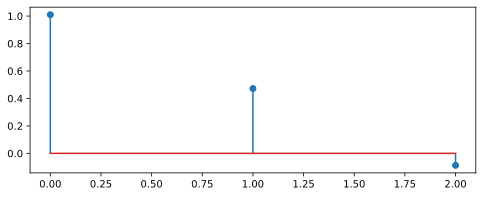

In [22]:
L = 3
ho = np.sinc(np.linspace(0,1.5,L))
ho = ho/np.linalg.norm(ho) # ground truth
h0 = np.zeros(L)
var_x = 1
var_v = 1e-3
#AR = np.array([1.0, 0.0])
AR = np.array([1.0, -0.6, 0.85])
#AR = np.array([1.0, -0.9, 0.95, -0.8, 0.8])

Rxx_est = autocorr_matrix_estimate(x, M = L)
eig = np.linalg.eigvals(Rxx)
chi = np.max(eig)/np.min(eig)
print(f'Eigenvalue spread: {chi:.4} \n')

rxx_est = Rxx_est[0,:]

plt.figure(figsize=(8, 3))
plt.stem(rxx_est)
plt.show()

##### PRUEBA MANUAL


In [23]:
NR = 1
N = int(200)

epsilon = 0.01
var_theta_0 = 2 # v_tilde_0
var_eta = 10*var_v
dx_factor = 1/25
min_std_deviations = 10
# NUEVO - LAPLACIAN
b_eta = 2

Algorithms = [sKF_integral_algorithm, sKF_algorithm, sKF_L_algorithm, sKF_L_integral_algorithm]

skf_parameters = np.void((f"sKF_integral",
                          epsilon,
                          var_theta_0,
                          var_eta,
                          dx_factor,
                          min_std_deviations), dtype=skf_int_params)

sKF_parameters_paper = np.void(("sKF_paper", epsilon, var_eta, var_theta_0), dtype=sKF_params)

sKF_L_parameters_paper = np.void(("sKF_L_paper", epsilon, b_eta, var_theta_0), dtype=sKF_L_params)


Alg_Parameters = [skf_parameters, sKF_parameters_paper, sKF_L_parameters_paper]

with ProgressBar(total=NR) as PBar:
  MC_measures = MC_Simulations_Modular_Variance(N, NR, ho, var_x, var_v, h0, Algorithms, Alg_Parameters, AR, PBar)



  0%|          | 0/1 [00:00<?, ?it/s]

IndexError: list index out of range

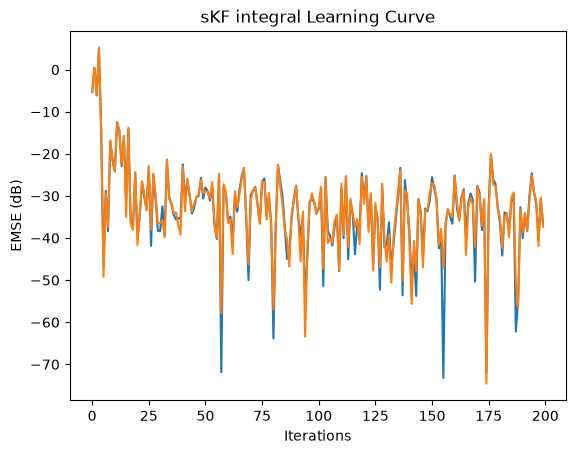

In [ ]:
plt.plot(10*np.log10(MC_measures["sKF_integral"]['Jex']))
plt.plot(10*np.log10(MC_measures["sKF_paper"]['Jex']))
plt.ylabel("EMSE (dB)")
plt.xlabel("Iterations")
plt.title("sKF integral Learning Curve")
plt.show()

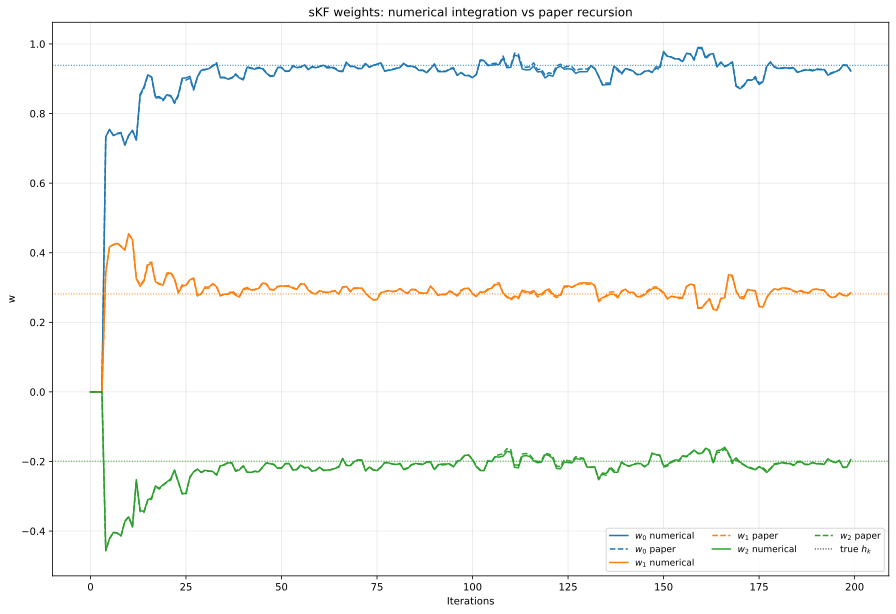

In [ ]:
h_num   = MC_measures["sKF_integral"]['h']
#h_L_num   = MC_measures["sKF_L_paper"]['h']
h_paper = MC_measures["sKF_paper"]['h']
L = h_num.shape[1]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(15, 10))
for k in range(L):
  c = colors[k % len(colors)]
  plt.plot(h_num[:, k],   color=c, linestyle='-',  label=f"$w_{k}$ numerical")
  plt.plot(h_paper[:, k], color=c, linestyle='--', label=f"$w_{k}$ paper")
  #plt.plot(h_L_num[:, k], color='k', linestyle='-.', label=f"$w_{k}$ paper Laplace")
  plt.axhline(ho[k], color=c, linestyle=':', linewidth=1)

plt.plot([], [], color='k', linestyle=':', linewidth=1, label="true $h_k$")
plt.ylabel("w")
plt.xlabel("Iterations")
plt.title("sKF weights: numerical integration vs paper recursion")
plt.legend(ncol=L, fontsize=9)
plt.grid(alpha=0.3)
# plt.savefig("figures/skf_weights.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#h_num   = MC_measures["sKF_integral"]['h']
h_L_num  = MC_measures["sKF_L_paper"]['h']
h_L_50_51   = MC_measures["sKF_L_paper"]['h']
#h_paper = MC_measures["sKF_paper"]['h']
L = h_num.shape[1]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(15, 10))
for k in range(L):
  c = colors[k % len(colors)]
  plt.plot(h_num[:, k],   color=c, linestyle='-',  label=f"$w_{k}$ numerical")
  plt.plot(h_paper[:, k], color=c, linestyle='--', label=f"$w_{k}$ paper")
  plt.plot(h_L_50_51[:, k], color='k', linestyle='-.', label=f"$w_{k}$ paper Laplace")
  plt.axhline(ho[k], color=c, linestyle=':', linewidth=1)

plt.plot([], [], color='k', linestyle=':', linewidth=1, label="true $h_k$")
plt.ylabel("w")
plt.xlabel("Iterations")
plt.title("sKF weights: numerical integration vs paper recursion")
plt.legend(ncol=L, fontsize=9)
plt.grid(alpha=0.3)
# plt.savefig("figures/skf_weights.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/0y/901xwybs5msgqgqgdw7c8r340000gn/T/ipykernel_55525/1785508473.py:10: RuntimeWarning: invalid value encountered in divide
  plt.plot(10*np.log10(np.abs(h_num[:, k] - h_paper[:,k])/np.abs(h_paper[:,k])),   color=c, linestyle='-',  label=f"$w_{k}$ numerical")


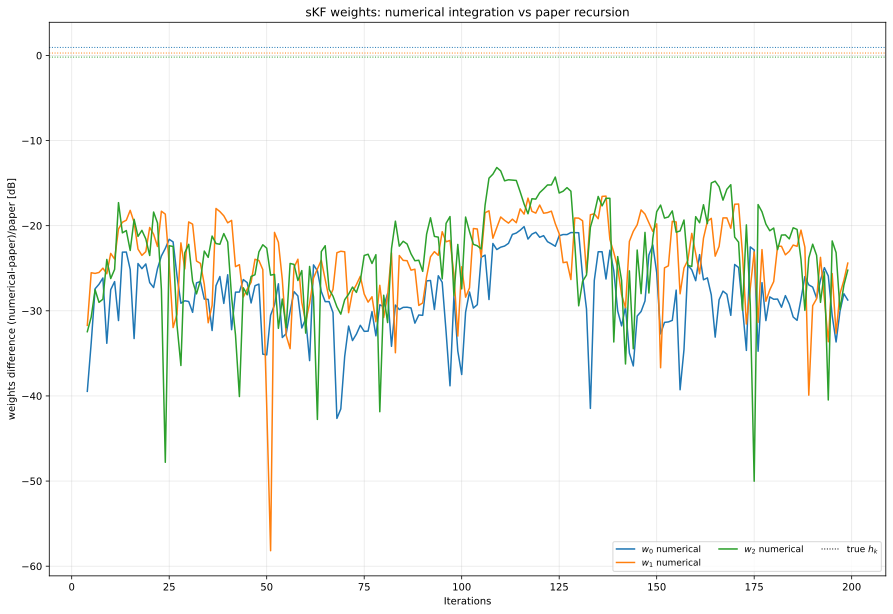

In [ ]:
h_num   = MC_measures["sKF_integral"]['h']
h_paper = MC_measures["sKF_paper"]['h']
L = h_num.shape[1]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(15, 10))
for k in range(L):
  c = colors[k % len(colors)]
  plt.plot(10*np.log10(np.abs(h_num[:, k] - h_paper[:,k])/np.abs(h_paper[:,k])),   color=c, linestyle='-',  label=f"$w_{k}$ numerical")
  #plt.plot(h_paper[:, k], color=c, linestyle='--', label=f"$w_{k}$ paper")
  plt.axhline(ho[k], color=c, linestyle=':', linewidth=1)

plt.plot([], [], color='k', linestyle=':', linewidth=1, label="true $h_k$")
plt.ylabel("weights difference (numerical-paper)/paper [dB]")
plt.xlabel("Iterations")
plt.title("sKF weights: numerical integration vs paper recursion")
plt.legend(ncol=L, fontsize=9)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
v_num   = MC_measures["sKF_integral"]['var']
v_paper = MC_measures["sKF_paper"]['var']
L = v_num.shape[1]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(9, 5))
# for k in range(L):
#   c = colors[k % len(colors)]
#   plt.plot(v_num[:, k],   color=c, linestyle='-',  label=f"$v_{k}$ numerical")
#   plt.plot(v_paper[:, k], color=c, linestyle='--', label=f"$v_{k}$ paper")
  # plt.axhline(ho[k], color=c, linestyle=':', linewidth=1)

plt.plot(v_num[:, 0],   color=c, linestyle='-',  label=f"v numerical")
plt.plot(v_paper[:, 0], color=c, linestyle='--', label=f"v paper")

#plt.plot([], [], color='k', linestyle=':', linewidth=1, label="true $h_k$")
plt.ylabel("v")
plt.xlabel("Iterations")
plt.title("sKF variance: numerical integration vs paper recursion")
plt.legend(ncol=L, fontsize=9)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
print(v_num.shape)

In [ ]:
v_num   = MC_measures["sKF_integral"]['var']
v_paper = MC_measures["sKF_paper"]['var']
L = v_num.shape[1]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(9, 5))
# for k in range(L):
#   c = colors[k % len(colors)]
#   plt.plot(v_num[:, k],   color=c, linestyle='-',  label=f"$v_{k}$ numerical")
#   plt.plot(v_paper[:, k], color=c, linestyle='--', label=f"$v_{k}$ paper")
  # plt.axhline(ho[k], color=c, linestyle=':', linewidth=1)

# plt.plot(v_num[:, 0],   color=c, linestyle='-',  label=f"v numerical")
# plt.plot(v_paper[:, 0], color=c, linestyle='--', label=f"v paper")

plt.plot(10*np.log10(np.abs(v_num[:, 0] - v_paper[:, 0])/np.abs(v_paper[:, 0])), color=c, linestyle='--', label=f"v paper")

#plt.plot([], [], color='k', linestyle=':', linewidth=1, label="true $h_k$")
plt.ylabel("(v_num-v_paper)/v_paper [dB]")
plt.xlabel("Iterations")
plt.title("sKF variance difference: numerical integration vs paper recursion LOG")
plt.legend(ncol=L, fontsize=9)
plt.grid(alpha=0.3)
plt.show()

##### GRID SEARCH

In [ ]:
import itertools, pickle, os

GRID = {
    "NR":                 [1, 3],
    "epsilon":            [1e-3, 1e-2],
    "var_theta_0":        [0.5, 2.0],
    "var_eta":            [1e-3, 1e-2],
    "dx_factor":          [1.0, 0.2],
    "min_std_deviations": [5, 10],
}

CACHE = "grid_results.pkl"
results = pickle.load(open(CACHE, "rb")) if os.path.exists(CACHE) else {}

@njit
def numba_seed(s): np.random.seed(s)

N=200

for combo in itertools.product(*GRID.values()):
    if combo in results:
        continue
    NR_, eps, vt0, veta, dxf, msd = combo

    p_int   = np.void(("sKF_integral", eps, vt0, veta, dxf, msd), dtype=skf_int_params)
    p_paper = np.void(("sKF_paper",    eps, veta, vt0),           dtype=sKF_params)

    numba_seed(0)
    results[combo] = MC_Simulations_Modular_Variance(
        N, NR_, ho, var_x, var_v, h0,
        [sKF_integral_algorithm, sKF_algorithm],
        [p_int, p_paper], AR)

    pickle.dump(results, open(CACHE, "wb"))   # save each cell, crash-safe
    print(combo, "done")

In [ ]:
DRAWS = [(draw_weights,      "weights: num vs paper"),
         (draw_weights_diff, "weights diff [dB]"),
         (draw_var,          "variance: num vs paper"),
         (draw_var_diff,     "variance diff [dB]")]

def grid_svg(fname="grid.svg", combos=None):
    combos = list(results.keys()) if combos is None else combos
    nrow, ncol = len(combos), len(DRAWS)
    fig, axes = plt.subplots(nrow, ncol, figsize=(7*ncol, 4*nrow),
                             sharey='col', squeeze=False,
                             constrained_layout=True)
    for i, combo in enumerate(combos):
        items = [f"{k}={v:g}" for k, v in zip(GRID, combo)]
        label = ", ".join(items[:3]) + "\n" + ", ".join(items[3:])
        for j, (draw, name) in enumerate(DRAWS):
            draw(axes[i, j], results[combo])
            axes[i, j].set_title(f"{name}\n{label}", fontsize=8)
            axes[i, j].grid(alpha=0.3)
    axes[0, 0].legend(fontsize=7)
    fig.savefig(fname, format="svg")
    plt.close(fig)

grid_svg("grid.svg")

In [ ]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def grid_plot(draw, title, sharey=True, ncol=2):
    combos = list(results.keys())
    nrow = int(np.ceil(len(combos)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(7*ncol, 4*nrow),
                             sharey=sharey, squeeze=False,
                             constrained_layout=True)
    for ax, combo in zip(axes.ravel(), combos):
        draw(ax, results[combo])
        items = [f"{k}={v:g}" for k, v in zip(GRID, combo)]
        ax.set_title(", ".join(items[:3]) + "\n" + ", ".join(items[3:]), fontsize=9)
        ax.grid(alpha=0.3)
    for ax in axes.ravel()[len(combos):]:
        ax.axis("off")
    axes[0, 0].legend(fontsize=7)
    fig.suptitle(title)
    plt.show()


def draw_weights(ax, r):                                    # cell 32
    num, pap = r["sKF_integral"]["h"], r["sKF_paper"]["h"]
    for k in range(num.shape[1]):
        c = colors[k % len(colors)]
        ax.plot(num[:, k], color=c, ls='-',  label=f"$w_{k}$ num")
        ax.plot(pap[:, k], color=c, ls='--', label=f"$w_{k}$ paper")
        ax.axhline(ho[k], color=c, ls=':', lw=1)

def draw_weights_diff(ax, r):                               # cell 33
    num, pap = r["sKF_integral"]["h"], r["sKF_paper"]["h"]
    for k in range(num.shape[1]):
        ax.plot(10*np.log10(np.abs(num[:, k] - pap[:, k]) / np.abs(pap[:, k])),
                color=colors[k % len(colors)], label=f"$w_{k}$")
    ax.axhline(10*np.log10(0.012), ls=":", c="k")           # regressor floor, 1.2%

def draw_var(ax, r):                                        # cell 34
    ax.plot(r["sKF_integral"]["var"][:, 0], '-',  label="v num")
    ax.plot(r["sKF_paper"]["var"][:, 0],    '--', label="v paper")

def draw_var_diff(ax, r):                                   # cell 36
    vn, vp = r["sKF_integral"]["var"][:, 0], r["sKF_paper"]["var"][:, 0]
    ax.plot(10*np.log10(np.abs(vn - vp) / np.abs(vp)))
    ax.axhline(10*np.log10(0.012), ls=":", c="k")


grid_plot(draw_weights,      "sKF weights: numerical integration vs paper recursion")
grid_plot(draw_weights_diff, "sKF weights difference (num-paper)/paper [dB]")
grid_plot(draw_var,          "sKF variance: numerical integration vs paper recursion",
          sharey=False)
grid_plot(draw_var_diff,     "sKF variance difference (num-paper)/paper [dB]")

In [ ]:
combos = list(results.keys())
ncol = 4; nrow = int(np.ceil(len(combos)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 3*nrow), sharey=True)

for ax, combo in zip(axes.ravel(), combos):
    r = results[combo]
    num, pap = r["sKF_integral"]["h"], r["sKF_paper"]["h"]
    rel = np.linalg.norm(num - pap, axis=1) / np.linalg.norm(pap, axis=1)
    ax.plot(10*np.log10(rel))
    ax.axhline(10*np.log10(0.012), ls=":", c="k")   # regressor floor, 1.2%
    ax.set_title(", ".join(f"{k}={v:g}" for k, v in zip(GRID, combo)), fontsize=7)

In [ ]:
MC_measures["sKF_integral"]['h']

##### Laplacian Likelihood

In [24]:
L = 3
ho = np.sinc(np.linspace(0, 1.5, L))
ho = ho / np.linalg.norm(ho)
h0 = np.zeros(L)
var_x = 1
var_v = 1e-3
# AR = np.array([1.0, 0.0])
AR = np.array([1.0, -0.6, 0.85])
# AR = np.array([1.0, -0.9, 0.95, -0.8, 0.8])

Rxx_est = autocorr_matrix_estimate(x, M=L)
eig = np.linalg.eigvals(Rxx)
chi = np.max(eig) / np.min(eig)
print(f"Eigenvalue spread: {chi:.4} \n")

Eigenvalue spread: (831.9+0j) 



In [48]:
NR = 1
N = int(200)

epsilon = 0.01
var_theta_0 = 2  # v_tilde_0
b_eta = 50 * np.sqrt(var_v)
dx_factor = 1/100
min_std_deviations = 10

Algorithms = [sKF_L_algorithm, sKF_L_integral_algorithm]

skf_L_parameters = np.void(
    ("sKF_L_integral", epsilon, var_theta_0, b_eta, dx_factor, min_std_deviations),
    dtype=skf_L_int_params,
)

sKF_L_parameters_paper = np.void(
    ("sKF_L_paper", epsilon, b_eta, var_theta_0), dtype=sKF_L_params
)

Alg_Parameters = [sKF_L_parameters_paper, skf_L_parameters]

with ProgressBar(total=NR) as PBar:
    MC_measures = MC_Simulations_Modular_Variance(
        N, NR, ho, var_x, var_v, h0, Algorithms, Alg_Parameters, AR, PBar
    )

  0%|          | 0/1 [00:00<?, ?it/s]

/var/folders/0y/901xwybs5msgqgqgdw7c8r340000gn/T/ipykernel_55525/787849217.py:335: RuntimeWarning: divide by zero encountered in log
  post_m  = np.nan_to_num(np.exp(np.log(prior_m) + np.log(likelihood))) # Search for numerical stable implementations
/var/folders/0y/901xwybs5msgqgqgdw7c8r340000gn/T/ipykernel_55525/787849217.py:335: RuntimeWarning: invalid value encountered in log
  post_m  = np.nan_to_num(np.exp(np.log(prior_m) + np.log(likelihood))) # Search for numerical stable implementations


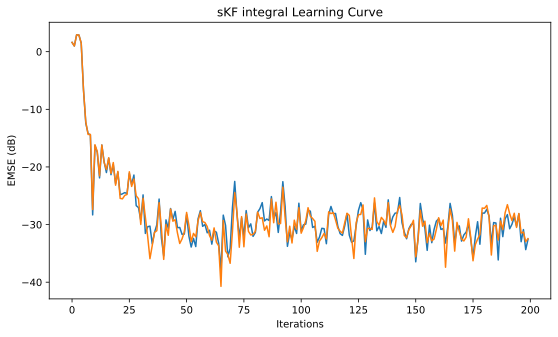

In [29]:
plt.figure(figsize=(9, 5))
plt.plot(10 * np.log10(MC_measures["sKF_L_paper"]["Jex"]))
plt.plot(10 * np.log10(MC_measures["sKF_L_integral"]["Jex"]))
plt.ylabel("EMSE (dB)")
plt.xlabel("Iterations")
plt.title("sKF integral Learning Curve")
plt.show()

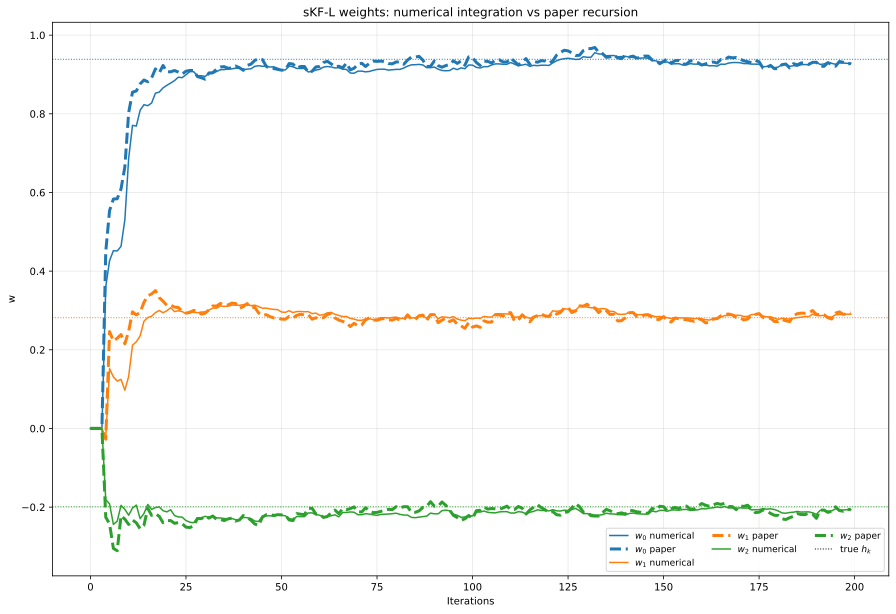

In [47]:
#h_num   = MC_measures["sKF_integral"]['h']
h_L_num   = MC_measures["sKF_L_integral"]['h']
#h_paper = MC_measures["sKF_paper"]['h']
h_L_paper = MC_measures["sKF_L_paper"]['h']

L = h_num.shape[1]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(15, 10))
for k in range(L):
  c = colors[k % len(colors)]
  plt.plot(h_L_num[:, k],   color=c, linestyle='-',  label=f"$w_{k}$ numerical")
  plt.plot(h_L_paper[:, k], color=c, linestyle='--', linewidth=3, label=f"$w_{k}$ paper")
  #plt.plot(h_L_num[:, k], color='k', linestyle='-.', label=f"$w_{k}$ paper Laplace")
  plt.axhline(ho[k], color=c, linestyle=':', linewidth=1)

plt.plot([], [], color='k', linestyle=':', linewidth=1, label="true $h_k$")
plt.ylabel("w")
plt.xlabel("Iterations")
plt.title("sKF-L weights: numerical integration vs paper recursion")
plt.legend(ncol=L, fontsize=9)
plt.grid(alpha=0.3)
# plt.savefig("figures/skf_weights.png", dpi=300, bbox_inches="tight")
plt.show()

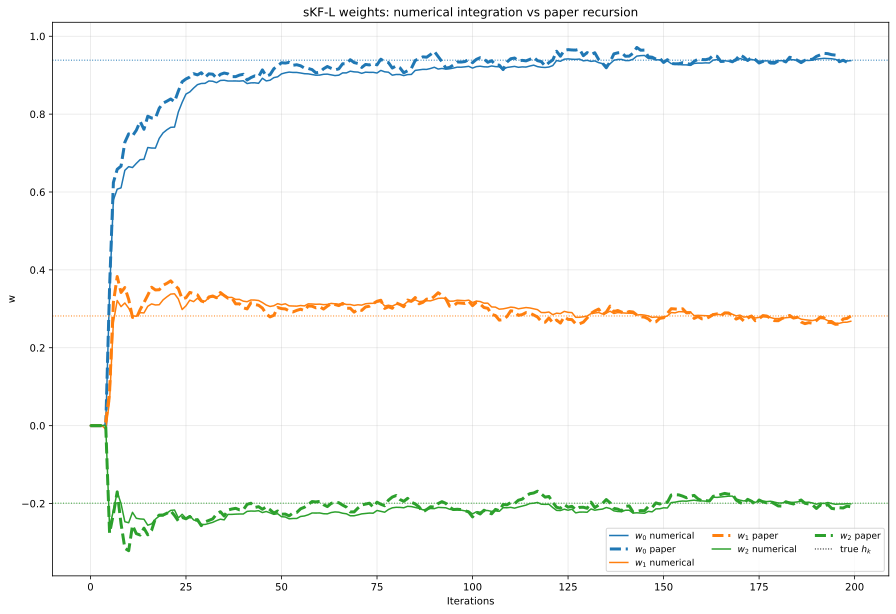

In [49]:
#h_num   = MC_measures["sKF_integral"]['h']
h_L_num   = MC_measures["sKF_L_integral"]['h']
#h_paper = MC_measures["sKF_paper"]['h']
h_L_paper = MC_measures["sKF_L_paper"]['h']

L = h_num.shape[1]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
%config InlineBackend.figure_format = 'svg'

plt.figure(figsize=(15, 10))
for k in range(L):
  c = colors[k % len(colors)]
  plt.plot(h_L_num[:, k],   color=c, linestyle='-',  label=f"$w_{k}$ numerical")
  plt.plot(h_L_paper[:, k], color=c, linestyle='--', linewidth=3, label=f"$w_{k}$ paper")
  #plt.plot(h_L_num[:, k], color='k', linestyle='-.', label=f"$w_{k}$ paper Laplace")
  plt.axhline(ho[k], color=c, linestyle=':', linewidth=1)

plt.plot([], [], color='k', linestyle=':', linewidth=1, label="true $h_k$")
plt.ylabel("w")
plt.xlabel("Iterations")
plt.title("sKF-L weights: numerical integration vs paper recursion")
plt.legend(ncol=L, fontsize=9)
plt.grid(alpha=0.3)
# plt.savefig("figures/skf_weights.png", dpi=300, bbox_inches="tight")
plt.show()